## **1. Mount Dataset (Hubungkan ke Google Drive)**

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## **2. Import Library**

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from collections import Counter
import pandas as pd


## **3. Load dan Preprocessing Dataset Gambar**
Di tahap ini, kita akan membaca semua gambar, menyeragamkan ukurannya (resize), dan mengubah gambar 2D/3D menjadi array 1D (flattening) agar bisa diproses oleh algoritma Machine Learning.

In [3]:

dataset_path = '/content/drive/MyDrive/Colab Notebooks/datasets/daging'

image_data = []
image_labels_asli = [] # Menyimpan label BABI, SAPI, OPLOSAN
IMG_SIZE = (64, 64)

print("Mulai membaca dataset...")

# Dictionary untuk menghitung jumlah gambar per folder
kategori_count = {'BABI': 0, 'OPLOSAN': 0, 'SAPI': 0}

for folder in os.listdir(dataset_path):
    if folder in kategori_count.keys():
        folder_path = os.path.join(dataset_path, folder)
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            try:
                img = cv2.imread(file_path)
                if img is None:
                    continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_resized = cv2.resize(img, IMG_SIZE)
                img_flattened = img_resized.flatten()

                image_data.append(img_flattened)
                image_labels_asli.append(folder)


                kategori_count[folder] += 1

            except Exception as e:
                pass

X = np.array(image_data)

print("--- Laporan Dataset ---")
print(f"Total gambar berhasil diload: {X.shape[0]}")
for kategori, jumlah in kategori_count.items():
    print(f"Jumlah daging {kategori}: {jumlah} gambar")
print(f"Dimensi setiap gambar setelah di-flatten: {X.shape[1]} piksel")

Mulai membaca dataset...
--- Laporan Dataset ---
Total gambar berhasil diload: 1947
Jumlah daging BABI: 977 gambar
Jumlah daging OPLOSAN: 206 gambar
Jumlah daging SAPI: 764 gambar
Dimensi setiap gambar setelah di-flatten: 12288 piksel


## **4. Ekstraksi Fitur (Dimensionality Reduction) dengan PCA**
Karena jumlah piksel sangat besar (64x64x3 = 12.288 kolom), kita gunakan PCA untuk mereduksinya. Sebelum itu, data harus di-scale (standardisasi).

In [4]:
# Standardisasi data agar skala piksel seragam
print("Melakukan scaling data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Menggunakan PCA
# mengambil 2 komponen utama (n_components=2) agar mudah divisualisasikan dalam grafik 2D X dan Y
print("Menjalankan PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensi data setelah direduksi PCA: {X_pca.shape}")
print(f"Rasio variansi yang dipertahankan: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

Melakukan scaling data...
Menjalankan PCA...
Dimensi data setelah direduksi PCA: (1947, 2)
Rasio variansi yang dipertahankan: 55.20%


## **5. Clustering dengan K-Means**
terapkan K-Means pada data hasil PCA tadi.

In [5]:
# Tentukan jumlah klaster. Asumsikan kita mencari 2 kelompok utama:
# Misalnya Daging Sapi Murni vs Daging Oplosan. Sesuaikan jika dataset punya lebih dari 2 jenis.
NUM_CLUSTERS = 3

print(f"Mulai K-Means Clustering dengan k={NUM_CLUSTERS}...")
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(X_pca)

# Label prediksi (0 atau 1) untuk tiap gambar
cluster_labels = kmeans.labels_

print("Clustering K-Means Selesai!")

Mulai K-Means Clustering dengan k=3...
Clustering K-Means Selesai!


## **6. Simpan Hasil Ekstraksi Fitur**


In [6]:
print("Menyiapkan data untuk disimpan...")

# Membuat nama kolom untuk fitur PCA
# Sesuaikan jumlahnya dengan n_components
kolom_pca = [f'PC{i+1}' for i in range(X_pca.shape[1])]

# Membuat DataFrame menggunakan Pandas
df_fitur = pd.DataFrame(data=X_pca, columns=kolom_pca)

# Menambahkan kolom Label Asli (Ground Truth) dan Hasil K-Means ke dalam tabel
df_fitur['Label_Asli'] = image_labels_asli
df_fitur['Klaster_KMeans'] = cluster_labels

# Menampilkan 5 baris pertama data sebagai preview
print("Preview Data yang akan disimpan:")
display(df_fitur.head())

# simpan di folder MyDrive
lokasi_simpan_excel = '/content/drive/MyDrive/Hasil_Ekstraksi_Fitur_Daging.xlsx'

# Menyimpan ke format Excel (.xlsx)
df_fitur.to_excel(lokasi_simpan_excel, index=False)
print(f"Berhasil disimpan sebagai Excel di: {lokasi_simpan_excel}")

Menyiapkan data untuk disimpan...
Preview Data yang akan disimpan:


,PC1,PC2,Label_Asli,Klaster_KMeans
0,0.614226,-28.027973,SAPI,2
1,-30.863237,-33.888893,SAPI,2
2,-19.611875,-40.881851,SAPI,2
3,-24.116248,-45.932249,SAPI,2
4,-27.534669,-69.757535,SAPI,2


Berhasil disimpan sebagai CSV di: /content/drive/MyDrive/Hasil_Ekstraksi_Fitur_Daging.csv
Berhasil disimpan sebagai Excel di: /content/drive/MyDrive/Hasil_Ekstraksi_Fitur_Daging.xlsx


## **7. Visualisasi Hasil Clustering**

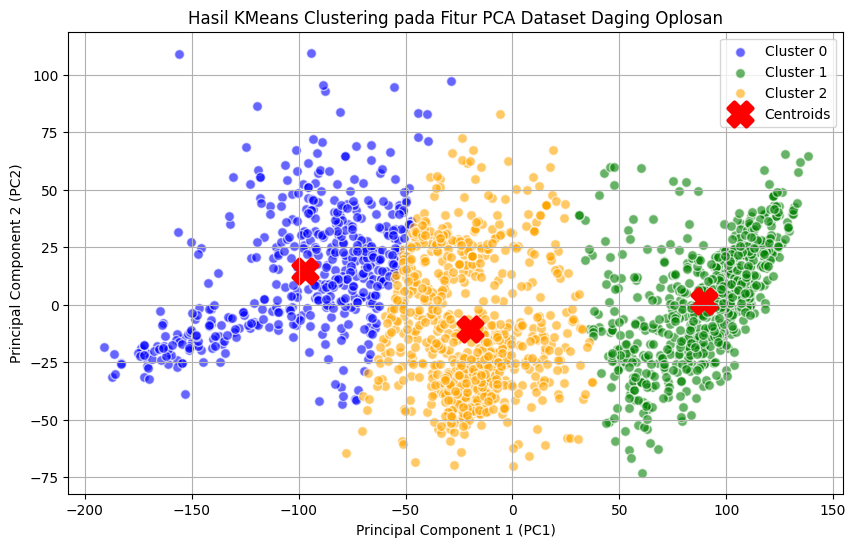

In [7]:
plt.figure(figsize=(10, 6))

colors = ['blue', 'green', 'orange', 'purple'] # Tambah warna jika klaster >

# Plot titik data hasil clustering
for i in range(NUM_CLUSTERS):
    # Ambil titik data yang masuk ke klaster 'i'
    points = X_pca[cluster_labels == i]
    plt.scatter(points[:, 0], points[:, 1], c=colors[i], label=f'Cluster {i}', alpha=0.6, edgecolors='w', s=50)

# Plot titik pusat klaster (Centroids)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroids', linewidths=3)

plt.title('Hasil KMeans Clustering pada Fitur PCA Dataset Daging Oplosan')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()
plt.grid(True)
plt.show()

## **8. Analisis dan Lihat Sampel Gambar**

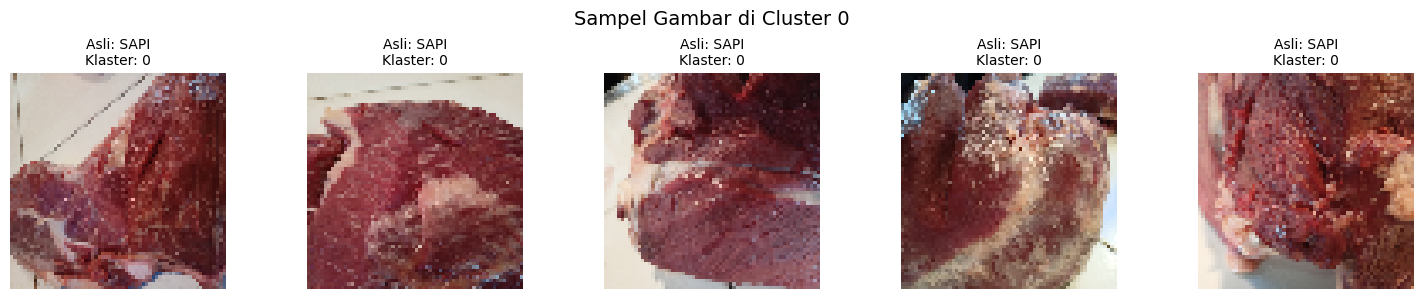

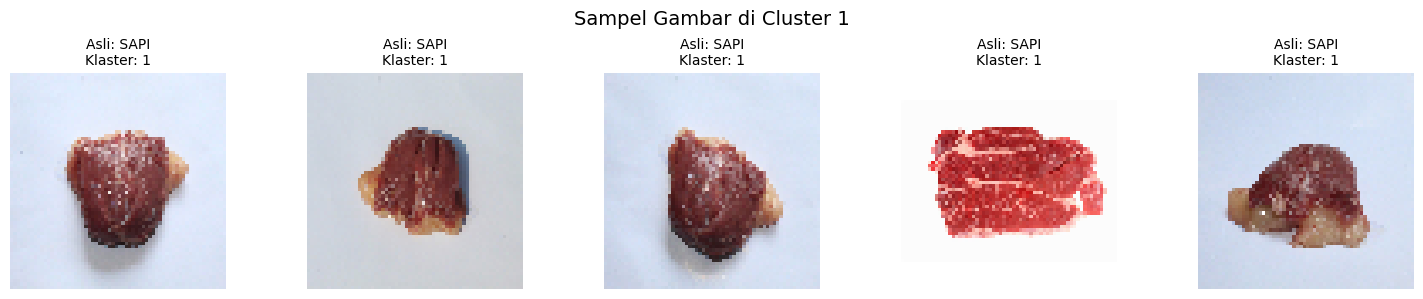

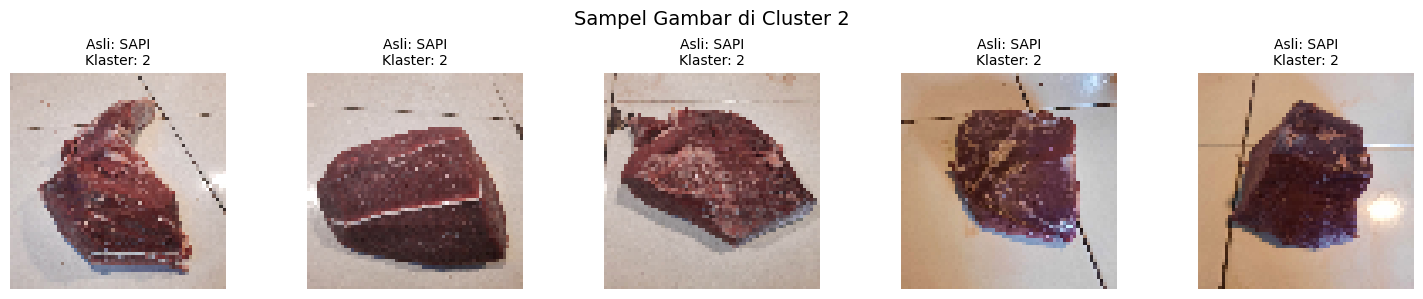

In [8]:
def show_cluster_samples(cluster_id, num_samples=5):
    # Cari indeks gambar yang masuk ke cluster_id
    indices = np.where(cluster_labels == cluster_id)[0]

    # Ambil sampel secara random atau beberapa yang pertama
    samples = indices[:num_samples]

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(samples):
        plt.subplot(1, num_samples, i+1)
        # Reshape kembali dari flatten array ke bentuk gambar asli
        img_reconstructed = X[idx].reshape(IMG_SIZE[0], IMG_SIZE[1], 3)
        plt.imshow(img_reconstructed)
        plt.title(f"Asli: {image_labels_asli[idx]}\nKlaster: {cluster_id}", fontsize=10)
        plt.axis('off')

    plt.suptitle(f'Sampel Gambar di Cluster {cluster_id}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Menampilkan sampel untuk tiap klaster
for c in range(NUM_CLUSTERS):
    show_cluster_samples(c)